# Feature Selection Comparison

This notebook checks whether the model actually needs all 330 features, or whether a smaller set would do just as well (or better). It ranks features by importance within each fold and compares LightGBM's performance using the top 330, 200, 150, 100, and 50 features.


## Import libraries

In [4]:
from pathlib import Path
import gc
import json
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.preprocessing import OrdinalEncoder

try:
    import lightgbm as lgb
except ImportError as error:
    raise ImportError("Install LightGBM first: pip install lightgbm") from error

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
print("LightGBM version:", lgb.__version__)
print("Libraries imported successfully.")

LightGBM version: 4.6.0
Libraries imported successfully.


## Set project paths

In [6]:
current_folder = Path.cwd().resolve()
project_root = current_folder.parent if current_folder.name == "notebooks" else current_folder

dataset_path = project_root / "data" / "modeling" / "final_feature_dataset.pkl"
training_ids_path = project_root / "data" / "modeling" / "splits" / "training_ids.csv"
test_ids_path = project_root / "data" / "modeling" / "splits" / "test_ids.csv"
folds_path = project_root / "data" / "modeling" / "splits" / "training_fold_assignments.csv"
configuration_path = project_root / "data" / "modeling" / "lightgbm_tuning_results" / "best_lightgbm_configuration.json"
rounds_path = project_root / "data" / "modeling" / "lightgbm_tuning_results" / "lightgbm_tuning_selected_rounds.csv"
result_folder = project_root / "data" / "modeling" / "feature_selection_results"
figure_folder = project_root / "reports" / "figures"
audit_folder = project_root / "reports" / "audits"

for folder in [result_folder, figure_folder, audit_folder]:
    folder.mkdir(parents=True, exist_ok=True)
for path in [dataset_path, training_ids_path, test_ids_path, folds_path, configuration_path, rounds_path]:
    assert path.exists(), f"Required file missing: {path}"

RANDOM_STATE = 2026
EXPECTED_TRAINING_ROWS = 246008
FEATURE_COUNTS = [330, 200, 150, 100, 50]
print("Project root:", project_root)
print("Feature sets:", FEATURE_COUNTS)

Project root: /Users/taranveersingh/A-MRP
Feature sets: [330, 200, 150, 100, 50]


## Load the training data and saved LightGBM settings

In [8]:
full_data = pd.read_pickle(dataset_path)
training_ids = pd.read_csv(training_ids_path)
test_ids = pd.read_csv(test_ids_path)
fold_assignments = pd.read_csv(folds_path)

training_data = full_data.merge(training_ids, on="SK_ID_CURR", how="inner", validate="one_to_one")
training_data = training_data.merge(fold_assignments, on="SK_ID_CURR", how="left", validate="one_to_one")
assert training_data["FOLD"].notna().all()

with open(configuration_path) as file:
    saved_configuration = json.load(file)
configuration_name = saved_configuration.pop("name")
rounds_table = pd.read_csv(rounds_path)
selected_rounds = rounds_table.loc[
    rounds_table["configuration"].eq(configuration_name),
    ["fold", "selected_rounds"]
].set_index("fold")["selected_rounds"].astype(int).to_dict()

print("Training rows:", len(training_data))
print("Final test rows kept separate:", len(test_ids))
print("Configuration:", configuration_name)
print("Rounds by fold:", selected_rounds)

Training rows: 246008
Final test rows kept separate: 61503
Configuration: lgb_leaves48_regularized
Rounds by fold: {1: 1396, 2: 934, 3: 1585, 4: 1406, 5: 710}


Reuses the already-tuned LightGBM configuration and round counts from notebook 26, rather than tuning anything new here.


## Prepare the predictors

In [11]:
excluded_columns = ["SK_ID_CURR", "TARGET", "FOLD", "CODE_GENDER"]
predictor_columns = [column for column in training_data.columns if column not in excluded_columns]
categorical_columns = training_data[predictor_columns].select_dtypes(exclude="number").columns.tolist()
numerical_columns = [column for column in predictor_columns if column not in categorical_columns]

X = training_data[predictor_columns].copy()
y = training_data["TARGET"].astype("int8").copy()
folds = training_data["FOLD"].astype(int).copy()
for column in categorical_columns:
    X[column] = X[column].fillna("Unknown").astype(str)

assert len(predictor_columns) == 330
assert set(FEATURE_COUNTS).issubset(set(range(1, len(predictor_columns) + 1)))
print("Predictors available:", len(predictor_columns))
print("Numerical predictors:", len(numerical_columns))
print("Categorical predictors:", len(categorical_columns))

Predictors available: 330
Numerical predictors: 318
Categorical predictors: 12


Same 330 predictors as everywhere else, this notebook just tests whether a smaller subset of them works just as well.


## Create helper functions

In [14]:
def make_preprocessor(selected_features):
    selected_numeric = [column for column in selected_features if column in numerical_columns]
    selected_categorical = [column for column in selected_features if column in categorical_columns]
    parts = []
    if selected_numeric:
        parts.append(("numeric", "passthrough", selected_numeric))
    if selected_categorical:
        parts.append((
            "categorical",
            OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=np.float32),
            selected_categorical,
        ))
    return ColumnTransformer(parts, sparse_threshold=0.0)

def build_lightgbm(number_of_rounds):
    return lgb.LGBMClassifier(
        n_estimators=number_of_rounds,
        **saved_configuration,
        objective="binary", max_bin=255,
        n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1,
    )

def calculate_metrics(actual, probability):
    return {
        "roc_auc": roc_auc_score(actual, probability),
        "pr_auc": average_precision_score(actual, probability),
    }

print("Helper functions created.")

Helper functions created.


Sets up the pieces needed for the comparison: a way to build a preprocessor for any subset of features, and a LightGBM builder using the already-tuned settings from notebook 26.


## Compare different feature-set sizes

For each fold, LightGBM first ranks all predictors using only that fold's training rows. The smaller model then uses the highest-ranked predictors and is evaluated on the untouched validation rows.

In [17]:
oof_predictions = pd.DataFrame({
    "SK_ID_CURR": training_data["SK_ID_CURR"].to_numpy(),
    "TARGET": y.to_numpy(),
    "FOLD": folds.to_numpy(),
})
for feature_count in FEATURE_COUNTS:
    oof_predictions[f"top_{feature_count}"] = np.nan

fold_metric_rows = []
importance_rows = []
selected_feature_rows = []

for fold_number in sorted(folds.unique()):
    print(f"\nFOLD {fold_number}")
    train_indices = np.flatnonzero(folds.ne(fold_number).to_numpy())
    valid_indices = np.flatnonzero(folds.eq(fold_number).to_numpy())
    number_of_rounds = selected_rounds[int(fold_number)]

    all_preprocessor = make_preprocessor(predictor_columns)
    X_train_all = all_preprocessor.fit_transform(X.iloc[train_indices]).astype("float32")
    X_valid_all = all_preprocessor.transform(X.iloc[valid_indices]).astype("float32")

    ranking_model = build_lightgbm(number_of_rounds)
    ranking_model.fit(X_train_all, y.iloc[train_indices])
    transformed_names = [name.split("__", 1)[-1] for name in all_preprocessor.get_feature_names_out()]
    fold_importance = pd.DataFrame({
        "feature": transformed_names,
        "gain_importance": ranking_model.booster_.feature_importance(importance_type="gain"),
    }).sort_values("gain_importance", ascending=False).reset_index(drop=True)
    fold_importance["fold"] = int(fold_number)
    fold_importance["rank"] = np.arange(1, len(fold_importance) + 1)
    importance_rows.append(fold_importance)

    ranked_features = fold_importance["feature"].tolist()
    for feature_count in FEATURE_COUNTS:
        selected_features = ranked_features[:feature_count]
        selected_feature_rows.extend([
            {"fold": int(fold_number), "feature_count": feature_count, "feature": feature, "rank": rank}
            for rank, feature in enumerate(selected_features, start=1)
        ])

        start_time = time.time()
        if feature_count == len(predictor_columns):
            model = ranking_model
            probability = model.predict_proba(X_valid_all)[:, 1]
        else:
            preprocessor = make_preprocessor(selected_features)
            X_train = preprocessor.fit_transform(X.iloc[train_indices][selected_features]).astype("float32")
            X_valid = preprocessor.transform(X.iloc[valid_indices][selected_features]).astype("float32")
            model = build_lightgbm(number_of_rounds)
            model.fit(X_train, y.iloc[train_indices])
            probability = model.predict_proba(X_valid)[:, 1]

        elapsed_minutes = (time.time() - start_time) / 60
        oof_predictions.loc[valid_indices, f"top_{feature_count}"] = probability
        metrics = calculate_metrics(y.iloc[valid_indices], probability)
        metrics.update({
            "fold": int(fold_number),
            "feature_count": feature_count,
            "selected_rounds": number_of_rounds,
            "training_minutes": elapsed_minutes,
        })
        fold_metric_rows.append(metrics)
        print(
            f"  Top {feature_count}: ROC AUC={metrics['roc_auc']:.5f}, "
            f"PR AUC={metrics['pr_auc']:.5f}, minutes={elapsed_minutes:.2f}"
        )

        if feature_count != len(predictor_columns):
            del preprocessor, X_train, X_valid, model
        del probability
        gc.collect()

    del all_preprocessor, X_train_all, X_valid_all, ranking_model
    gc.collect()

fold_metrics = pd.DataFrame(fold_metric_rows)
feature_importance_by_fold = pd.concat(importance_rows, ignore_index=True)
selected_features_by_fold = pd.DataFrame(selected_feature_rows)
print("\nAll feature-selection comparisons completed.")


FOLD 1


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Top 330: ROC AUC=0.79116, PR AUC=0.28621, minutes=0.02


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Top 200: ROC AUC=0.79044, PR AUC=0.28539, minutes=0.63


...

  Top 150: ROC AUC=0.79023, PR AUC=0.28514, minutes=0.43


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Top 100: ROC AUC=0.78903, PR AUC=0.28057, minutes=0.36


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Top 50: ROC AUC=0.78418, PR AUC=0.27288, minutes=0.20

All feature-selection comparisons completed.


## Compare the overall results

In [19]:
overall_rows = []
for feature_count in FEATURE_COUNTS:
    column = f"top_{feature_count}"
    metrics = calculate_metrics(oof_predictions["TARGET"], oof_predictions[column])
    feature_folds = fold_metrics.loc[fold_metrics["feature_count"].eq(feature_count)]
    metrics.update({
        "feature_set": column,
        "feature_count": feature_count,
        "fold_roc_auc_mean": feature_folds["roc_auc"].mean(),
        "fold_roc_auc_std": feature_folds["roc_auc"].std(),
        "fold_pr_auc_mean": feature_folds["pr_auc"].mean(),
        "total_training_minutes": feature_folds["training_minutes"].sum(),
    })
    overall_rows.append(metrics)

overall_metrics = pd.DataFrame(overall_rows).sort_values(
    ["roc_auc", "pr_auc"], ascending=False
).reset_index(drop=True)
best_feature_count = int(overall_metrics.iloc[0]["feature_count"])
overall_metrics.round(6)

,roc_auc,pr_auc,feature_set,feature_count,fold_roc_auc_mean,fold_roc_auc_std,fold_pr_auc_mean,total_training_minutes
0,0.789661,0.282529,top_330,330,0.789764,0.002450,0.283200,0.078213
1,0.789149,0.282511,top_200,200,0.789255,0.003176,0.283021,2.979876
2,0.788593,0.280762,top_150,150,0.788691,0.002797,0.281215,2.988566
3,0.786429,0.276994,top_100,100,0.786529,0.003386,0.277474,2.311160
4,0.781928,0.271027,top_50,50,0.781999,0.003739,0.271496,1.458384


The full 330-feature set wins. Performance drops steadily as fewer features are kept, from 0.789661 at 330 down to 0.781928 at just 50, so trimming the feature set does not help here.


## Build a stable feature ranking across the five folds

In [22]:
consensus_ranking = feature_importance_by_fold.groupby("feature").agg(
    mean_gain_importance=("gain_importance", "mean"),
    mean_rank=("rank", "mean"),
).reset_index()
consensus_ranking = consensus_ranking.sort_values(
    ["mean_gain_importance", "mean_rank"], ascending=[False, True]
).reset_index(drop=True)
consensus_ranking["overall_rank"] = np.arange(1, len(consensus_ranking) + 1)

for feature_count in FEATURE_COUNTS:
    selected = selected_features_by_fold.loc[
        selected_features_by_fold["feature_count"].eq(feature_count), "feature"
    ].value_counts()
    consensus_ranking[f"selected_in_folds_top_{feature_count}"] = (
        consensus_ranking["feature"].map(selected).fillna(0).astype(int)
    )

consensus_ranking.head(30).round(4)

,feature,mean_gain_importance,mean_rank,overall_rank,selected_in_folds_top_330,selected_in_folds_top_200,selected_in_folds_top_150,selected_in_folds_top_100,selected_in_folds_top_50
0,EXT_SOURCE_MEAN,156063.1126,1.0,1,5,5,5,5,5
1,APP_EXT_MEAN_SQUARED,51728.1894,2.0,2,5,5,5,5,5
2,APP_CREDIT_ANNUITY_RATIO,21489.7923,3.0,3,5,5,5,5,5
3,BUREAU_DEBT_CREDIT_RATIO_MAX,16172.2278,4.0,4,5,5,5,5,5
4,APP_EXT_2_3_PRODUCT,10851.6429,7.0,5,5,5,5,5,5
5,APP_CREDIT_GOODS_DIFFERENCE,10529.2454,7.4,6,5,5,5,5,5
6,CC_RECENT_12M_UTILIZATION_MAX,10105.4508,7.8,7,5,5,5,5,5
7,APP_EMPLOYED_AGE_RATIO,10048.9247,8.8,8,5,5,5,5,5
8,PREV_CREDIT_APPLICATION_RATIO_MEAN,9951.5606,8.6,9,5,5,5,5,5
9,AMT_ANNUITY,9752.4042,8.8,10,5,5,5,5,5


Averages each feature's importance and rank across all five folds, giving one stable ranking instead of five slightly different ones. EXT_SOURCE_MEAN comes out on top by a wide margin.


## Plot the feature-count comparison

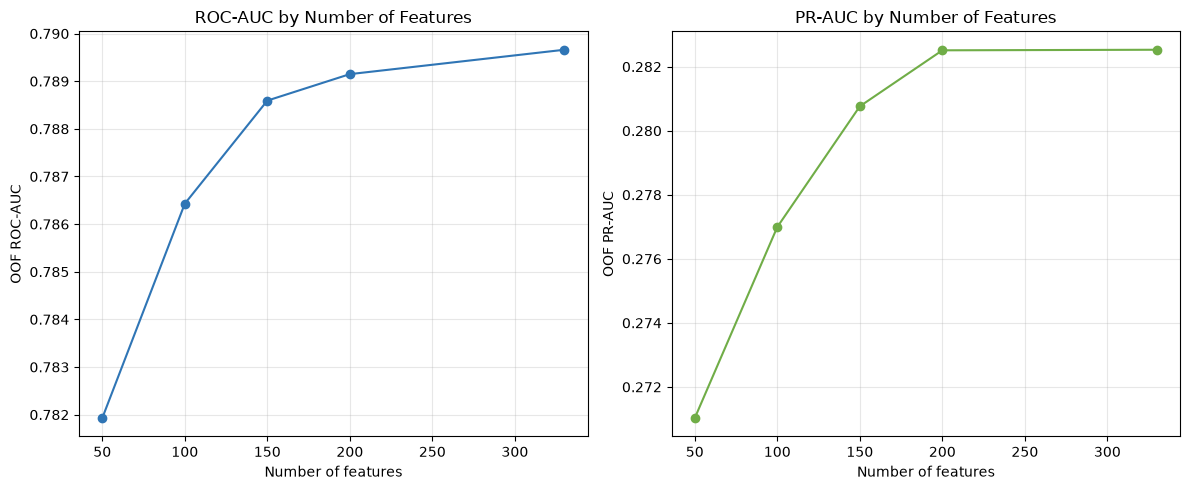

Figure saved: /Users/taranveersingh/A-MRP/reports/figures/feature_selection_comparison.png


In [25]:
plot_data = overall_metrics.sort_values("feature_count")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(plot_data["feature_count"], plot_data["roc_auc"], marker="o", color="#2f75b5")
axes[0].set_title("ROC-AUC by Number of Features")
axes[0].set_xlabel("Number of features")
axes[0].set_ylabel("OOF ROC-AUC")
axes[0].grid(alpha=0.3)

axes[1].plot(plot_data["feature_count"], plot_data["pr_auc"], marker="o", color="#70ad47")
axes[1].set_title("PR-AUC by Number of Features")
axes[1].set_xlabel("Number of features")
axes[1].set_ylabel("OOF PR-AUC")
axes[1].grid(alpha=0.3)

fig.tight_layout()
figure_path = figure_folder / "feature_selection_comparison.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("Figure saved:", figure_path)

Shows the same pattern visually, performance drops as fewer features are kept, with no point where a smaller set does better.


## Validate and save the results

In [28]:
test_id_set = set(test_ids["SK_ID_CURR"])
validation_checks = pd.DataFrame([
    {"check": "Complete training dataset used", "passed": len(X) == EXPECTED_TRAINING_ROWS},
    {"check": "All five folds used", "passed": set(fold_metrics["fold"]) == set(folds.unique())},
    {"check": "Every feature set tested on every fold", "passed": fold_metrics.groupby("feature_count")["fold"].nunique().eq(5).all()},
    {"check": "All OOF predictions complete", "passed": not oof_predictions[[f"top_{n}" for n in FEATURE_COUNTS]].isna().any().any()},
    {"check": "One OOF row per training applicant", "passed": len(oof_predictions) == EXPECTED_TRAINING_ROWS and oof_predictions["SK_ID_CURR"].is_unique},
    {"check": "Final test excluded", "passed": not oof_predictions["SK_ID_CURR"].isin(test_id_set).any()},
    {"check": "Protected gender excluded", "passed": "CODE_GENDER" not in predictor_columns},
    {"check": "Requested feature counts tested", "passed": set(fold_metrics["feature_count"]) == set(FEATURE_COUNTS)},
    {"check": "Metrics are finite", "passed": np.isfinite(overall_metrics.select_dtypes(include="number").to_numpy()).all()},
])
display(validation_checks)
assert validation_checks["passed"].all(), "At least one feature-selection check failed."

oof_predictions.to_pickle(result_folder / "feature_selection_oof_predictions.pkl")
oof_predictions.to_csv(result_folder / "feature_selection_oof_predictions.csv", index=False)
fold_metrics.to_csv(result_folder / "feature_selection_fold_metrics.csv", index=False)
overall_metrics.to_csv(result_folder / "feature_selection_overall_metrics.csv", index=False)
feature_importance_by_fold.to_csv(result_folder / "feature_importance_by_fold.csv", index=False)
selected_features_by_fold.to_csv(result_folder / "selected_features_by_fold.csv", index=False)
consensus_ranking.to_csv(result_folder / "consensus_feature_ranking.csv", index=False)
validation_checks.to_csv(audit_folder / "feature_selection_validation.csv", index=False)

print("All validation checks passed.")
print("Best feature count by OOF ROC-AUC:", best_feature_count)
print("Results saved in:", result_folder)
print("Final test evaluations performed: 0")

,check,passed
0,Complete training dataset used,True
1,All five folds used,True
2,Every feature set tested on every fold,True
3,All OOF predictions complete,True
4,One OOF row per training applicant,True
5,Final test excluded,True
6,Protected gender excluded,True
7,Requested feature counts tested,True
8,Metrics are finite,True


All validation checks passed.
Best feature count by OOF ROC-AUC: 330
Results saved in: /Users/taranveersingh/A-MRP/data/modeling/feature_selection_results
Final test evaluations performed: 0


All checks passed.


## Conclusion

The full 330-feature set gave the best OOF result (ROC-AUC 0.789661), and performance dropped off steadily as features were removed, down to 0.781928 at just 50 features. In other words, trimming features did not help here, it only cost performance. The full feature set is kept for every model going forward, this notebook's job was to confirm that decision rather than find a smaller set.
